## Transfer Learning
This is about transfering the learning of a already well trained model into the model you are building. Instead of your model learning from the scrach, it can build on a exsisting trained model. For example we can use the VGG model to build and train a model to catogories dogs and cats. VGG itself does not have cat and dog categories(they have breads of cats and dogs), but we can use its learnings to train our model with cat and dog images to recognise them. The trained models help us with their pre trained filters. The pre trained models should have some form of overlap between their categories and the categories we are taining for this to be possible. 

So here we will be using the pre trained model's convolution layers and our own catogorization layers. In general in training we don't change the pre trained model's convolution parameters during back propagation, only the weights and bias of our own catogorization layers are trained. But there are exceptions to this, where we will change the pre trained filters of the lower layers of convolution during back propogation, this is called fine tuning. Also we can add our own chunks in addition to the pre trained model's chunks, we can try different architectures like this to improve the model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

In [2]:
# include_top=False asks it to remove the top categorical layers and give only the convolution layers
# with this option it allows us to change the shape of the input
# we don't need to re-train the model if input shape channges, only flattening layer changes
vgg = tf.keras.applications.vgg16.VGG16(include_top=False, input_shape=(224,224,3))
vgg.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

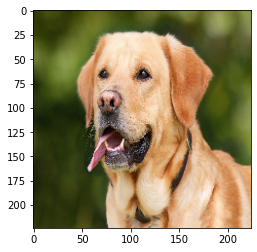

In [10]:
image = cv2.cvtColor(cv2.imread("labrador.jpg"), cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224,224))
plt.imshow(image)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1, 224, 224, 3)


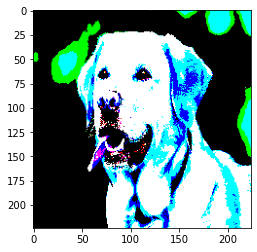

In [11]:
image = tf.keras.applications.vgg16.preprocess_input(image)
image = np.expand_dims(image, axis=0)
print(image.shape)
plt.imshow(image[0])

1/1 [==============================] - 0s 122ms/step
(1, 7, 7, 512)


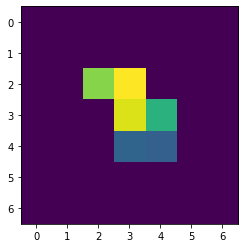

In [14]:
features = vgg.predict(image)
print(features.shape) #1 - image, 7 - width, 7 - height, 512 - features
plt.imshow(features[0, :, :, 0]) //plot the first feature map

In [ ]:
# Freeze the conv layers of vgg

## 01/04 - 01:04:00